In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
from scipy.io import loadmat

Mounted at /content/drive


In [2]:
BASE_DIR = '/content/drive/MyDrive/CSE465:EEG/SEED-VIG'   # <-- change if needed

# Folder that has the 17-channel 5-band EEG feature .mat files
EEG_5BAND_DIR = os.path.join(BASE_DIR, 'EEG_Feature_5Bands')

# Folder that has the PERCLOS label .mat files
LABEL_DIR     = os.path.join(BASE_DIR, 'perclos_labels')

print("EEG 5-band dir :", EEG_5BAND_DIR)
print("Label dir      :", LABEL_DIR)

# ============================
# 3. List all .mat files
# ============================
eeg_files   = sorted(glob.glob(os.path.join(EEG_5BAND_DIR, '*.mat')))
label_files = sorted(glob.glob(os.path.join(LABEL_DIR, '*.mat')))

print(f"Found {len(eeg_files)} EEG 5-band files")
print(f"Found {len(label_files)} label files\n")

print("EEG files:")
for f in eeg_files:
    print(" ", os.path.basename(f))
print("\nLabel files:")
for f in label_files:
    print(" ", os.path.basename(f))

# ============================
# 4. Helper: pick a feature key
# ============================
def pick_eeg_feature_key(mat_dict):
    """
    Try common SEED-VIG keys and return the first one that exists.
    You can change this list if your keys are different.
    """
    candidate_keys = ['de_LDS', 'de_movingAve', 'psd_LDS', 'psd_movingAve']
    for k in candidate_keys:
        if k in mat_dict:
            return k
    return None

# ============================
# 5. Inspect first few subjects
# ============================
print("\n=== Inspecting EEG feature files ===\n")

for idx, eeg_path in enumerate(eeg_files):
    print(f"Subject {idx} | file: {os.path.basename(eeg_path)}")
    mat = loadmat(eeg_path)
    print("  Keys:", [k for k in mat.keys() if not k.startswith('__')])

    feat_key = pick_eeg_feature_key(mat)
    if feat_key is None:
        print("  !! No known feature key found (de_LDS/de_movingAve/psd_*)")
    else:
        feat = mat[feat_key]
        print(f"  Using key '{feat_key}' with shape:", feat.shape)

        # If shape is (17, 885, 5), this is what we expect
        if feat.ndim == 3:
            print(f"  -> dims interpreted as: channels={feat.shape[0]}, "
                  f"samples={feat.shape[1]}, bands={feat.shape[2]}")
    print("-" * 50)

# ============================
# 6. Inspect label files
# ============================
print("\n=== Inspecting label files ===\n")

for idx, label_path in enumerate(label_files):
    print(f"Subject {idx} | file: {os.path.basename(label_path)}")
    mat = loadmat(label_path)
    keys = [k for k in mat.keys() if not k.startswith('__')]
    print("  Keys:", keys)

    # Try to guess label key
    label_key = None
    for cand in ['PERCLOS', 'perclos', 'label', 'labels', 'y']:
        if cand in mat:
            label_key = cand
            break

    if label_key is None:
        print("  !! No obvious label key found (PERCLOS/perclos/label/labels/y)")
    else:
        y = mat[label_key].squeeze()
        print(f"  Using key '{label_key}' with shape:", y.shape)

        # Check length vs EEG samples (885 expected)
        if eeg_files:
            eeg_example = loadmat(eeg_files[min(idx, len(eeg_files)-1)])
            feat_key = pick_eeg_feature_key(eeg_example)
            if feat_key is not None:
                feat = eeg_example[feat_key]
                n_samples = feat.shape[1]  # expecting 885
                print(f"  -> EEG samples for this subject (from features): {n_samples}")
                print(f"  -> Label length: {len(y)}")
                if len(y) == n_samples:
                    print("  OK: label count matches EEG windows.")
                else:
                    print("  WARNING: label count does NOT match EEG windows.")
    print("-" * 50)

# ============================
# 7. (Optional) Build stacked arrays to confirm global shapes
# ============================
print("\n=== Building stacked arrays (just to verify shapes) ===\n")

all_X = []
all_y = []
all_subj_ids = []

for subj_id, (eeg_path, label_path) in enumerate(zip(eeg_files, label_files)):
    eeg_mat = loadmat(eeg_path)
    feat_key = pick_eeg_feature_key(eeg_mat)
    if feat_key is None:
        print(f"Skipping subject {subj_id}: no feature key found.")
        continue

    X = eeg_mat[feat_key]      # shape: (17, n_samples, 5) expected
    if X.ndim != 3:
        print(f"Skipping subject {subj_id}: unexpected EEG shape {X.shape}")
        continue

    # rearrange to (n_samples, 17, 5)
    X = np.transpose(X, (1, 0, 2))

    label_mat = loadmat(label_path)
    label_key = None
    for cand in ['PERCLOS', 'perclos', 'label', 'labels', 'y']:
        if cand in label_mat:
            label_key = cand
            break
    if label_key is None:
        print(f"Skipping subject {subj_id}: no label key found.")
        continue

    y = label_mat[label_key].squeeze()
    if len(y) != X.shape[0]:
        print(f"Skipping subject {subj_id}: label length {len(y)} "
              f"!= EEG samples {X.shape[0]}")
        continue

    all_X.append(X)
    all_y.append(y)
    all_subj_ids.append(np.full(len(y), subj_id, dtype=int))

# Stack across subjects
if all_X:
    X_all = np.concatenate(all_X, axis=0)        # (N_total, 17, 5)
    y_all = np.concatenate(all_y, axis=0)        # (N_total,)
    subj_all = np.concatenate(all_subj_ids, 0)   # (N_total,)

    print("Final stacked shapes:")
    print("  X_all   :", X_all.shape)
    print("  y_all   :", y_all.shape)
    print("  subj_all:", subj_all.shape)
else:
    print("No valid subjects were found. Check keys and paths above.")


EEG 5-band dir : /content/drive/MyDrive/CSE465:EEG/SEED-VIG/EEG_Feature_5Bands
Label dir      : /content/drive/MyDrive/CSE465:EEG/SEED-VIG/perclos_labels
Found 23 EEG 5-band files
Found 23 label files

EEG files:
  10_20151125_noon.mat
  11_20151024_night.mat
  12_20150928_noon.mat
  13_20150929_noon.mat
  14_20151014_night.mat
  15_20151126_night.mat
  16_20151128_night.mat
  17_20150925_noon.mat
  18_20150926_noon.mat
  19_20151114_noon.mat
  1_20151124_noon_2.mat
  20_20151129_night.mat
  21_20151016_noon.mat
  2_20151106_noon.mat
  3_20151024_noon.mat
  4_20151105_noon.mat
  4_20151107_noon.mat
  5_20141108_noon.mat
  5_20151012_night.mat
  6_20151121_noon.mat
  7_20151015_night.mat
  8_20151022_noon.mat
  9_20151017_night.mat

Label files:
  10_20151125_noon.mat
  11_20151024_night.mat
  12_20150928_noon.mat
  13_20150929_noon.mat
  14_20151014_night.mat
  15_20151126_night.mat
  16_20151128_night.mat
  17_20150925_noon.mat
  18_20150926_noon.mat
  19_20151114_noon.mat
  1_2015112

X_all shape: (20355, 17, 5)
y_all shape: (20355,)
subj_all shape: (20355,)

NaN counts:
  X_all NaNs: 0
  y_all NaNs: 0
  subj_all NaNs: 0

Feature value range (before normalization):
  X_all min: 13.544877334413751
  X_all max: 38.414795321436785

Label (PERCLOS) range:
  y_all min: 0.022066666666666665
  y_all max: 0.9999999999999996


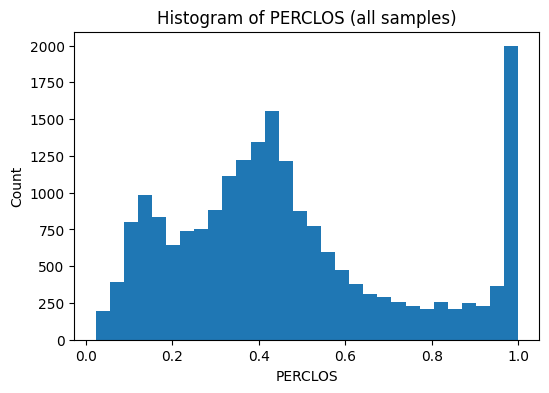


Binary labels (threshold = 0.35):
  alert (0): 7405 samples
  fatigued (1): 12950 samples

Per-subject PERCLOS stats:


,subject_id,n_samples,perclos_mean,perclos_std,perclos_min,perclos_max,fatigued_ratio(>=0.35)
0,0,885,0.431359,0.145579,0.107508,0.799853,0.691525
1,1,885,0.403041,0.131753,0.083283,0.780499,0.633898
2,2,885,0.633889,0.376890,0.127717,1.000000,0.637288
3,3,885,0.736411,0.200610,0.436100,1.000000,1.000000
4,4,885,0.526837,0.228094,0.189550,1.000000,0.745763
5,5,885,0.430214,0.163512,0.205457,0.955541,0.673446
6,6,885,0.674299,0.323285,0.049041,1.000000,0.771751
7,7,885,0.518496,0.199490,0.330660,1.000000,0.970621
8,8,885,0.558000,0.339682,0.092593,1.000000,0.520904
9,9,885,0.457827,0.117619,0.194420,0.728494,0.836158


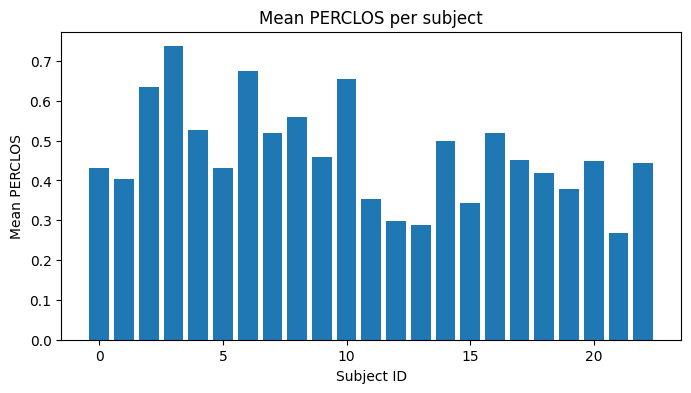


Average DE per band (across all subjects & channels):
  delta: mean=24.8671, std=2.0508
  theta: mean=22.7666, std=1.9592
  alpha: mean=22.3223, std=2.0822
  beta: mean=20.4380, std=1.7854
  gamma: mean=18.8566, std=2.0607


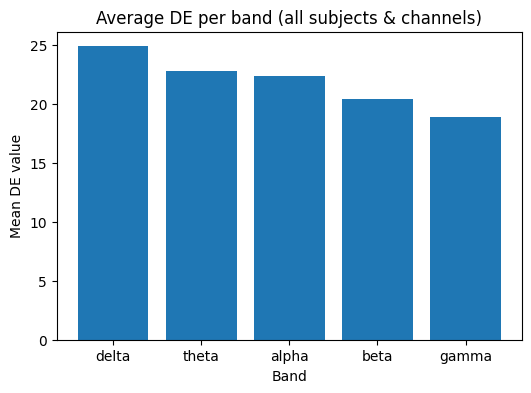

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# 1. Basic sanity checks
# ============================

print("X_all shape:", X_all.shape)   # (N, 17, 5)
print("y_all shape:", y_all.shape)   # (N,)
print("subj_all shape:", subj_all.shape)

print("\nNaN counts:")
print("  X_all NaNs:", np.isnan(X_all).sum())
print("  y_all NaNs:", np.isnan(y_all).sum())
print("  subj_all NaNs:", np.isnan(subj_all).sum())

print("\nFeature value range (before normalization):")
print("  X_all min:", X_all.min())
print("  X_all max:", X_all.max())

print("\nLabel (PERCLOS) range:")
print("  y_all min:", y_all.min())
print("  y_all max:", y_all.max())

# ============================
# 2. PERCLOS distribution
# ============================

plt.figure(figsize=(6,4))
plt.hist(y_all, bins=30)
plt.title("Histogram of PERCLOS (all samples)")
plt.xlabel("PERCLOS")
plt.ylabel("Count")
plt.show()

# Binary label using threshold 0.35
threshold = 0.35
y_cls = (y_all >= threshold).astype(int)
unique, counts = np.unique(y_cls, return_counts=True)
print("\nBinary labels (threshold = 0.35):")
for u, c in zip(unique, counts):
    label_name = "alert (0)" if u == 0 else "fatigued (1)"
    print(f"  {label_name}: {c} samples")

# ============================
# 3. Per-subject label stats
# ============================

subject_ids = np.unique(subj_all)
rows = []
for sid in subject_ids:
    mask = (subj_all == sid)
    y_subj = y_all[mask]
    rows.append({
        "subject_id": sid,
        "n_samples": len(y_subj),
        "perclos_mean": float(np.mean(y_subj)),
        "perclos_std": float(np.std(y_subj)),
        "perclos_min": float(np.min(y_subj)),
        "perclos_max": float(np.max(y_subj)),
        "fatigued_ratio(>=0.35)": float(np.mean(y_subj >= threshold))
    })

df_subj = pd.DataFrame(rows)
print("\nPer-subject PERCLOS stats:")
display(df_subj)

# Optional: quick bar plot of mean PERCLOS per subject
plt.figure(figsize=(8,4))
plt.bar(df_subj["subject_id"], df_subj["perclos_mean"])
plt.xlabel("Subject ID")
plt.ylabel("Mean PERCLOS")
plt.title("Mean PERCLOS per subject")
plt.show()

# ============================
# 4. Rough band-wise feature patterns
#    (just sanity, not deep analysis)
# ============================

# X_all shape: (N, 17, 5) → axes: samples, channels, bands
band_names = ["delta", "theta", "alpha", "beta", "gamma"]

# average over samples and channels -> (5,)
mean_per_band = X_all.mean(axis=(0, 1))
std_per_band  = X_all.std(axis=(0, 1))

print("\nAverage DE per band (across all subjects & channels):")
for i, name in enumerate(band_names):
    print(f"  {name}: mean={mean_per_band[i]:.4f}, std={std_per_band[i]:.4f}")

plt.figure(figsize=(6,4))
plt.bar(band_names, mean_per_band)
plt.xlabel("Band")
plt.ylabel("Mean DE value")
plt.title("Average DE per band (all subjects & channels)")
plt.show()
